In [ ]:
#refer the requirements to get the necessary library versions

In [52]:
import random
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils import shuffle
from sklearn.metrics import confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential,load_model,model_from_json
from tensorflow.keras.layers import Activation,Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import CategoricalCrossentropy

<h1>Data Prepration</h1>

In [19]:
train_labels = []
train_samples = []
random.seed(10)

for i in range(50):
    random_young = random.randint(13,64)
    train_samples.append(random_young)
    train_labels.append(1)


    random_old = random.randint(65,100)
    train_samples.append(random_old)
    train_labels.append(0)


for i in range(1000):
    random_young = random.randint(13,64)
    train_samples.append(random_young)
    train_labels.append(0)


    random_old = random.randint(65,100)
    train_samples.append(random_old)
    train_labels.append(1)



test_labels = []
test_samples = []


for i in range(50):
    random_young = random.randint(13,64)
    test_samples.append(random_young)
    test_labels.append(1)


    random_old = random.randint(65,100)
    test_samples.append(random_old)
    test_labels.append(0)


for i in range(1000):
    random_young = random.randint(13,64)
    test_samples.append(random_young)
    test_labels.append(0)


    random_old = random.randint(65,100)
    test_samples.append(random_old)
    test_labels.append(1)




In [ ]:
train_samples = np.array(train_samples)
train_labels = np.array(train_labels)
train_samples,train_labels = shuffle(train_samples,train_labels)
minmax_scaler = MinMaxScaler(feature_range=(0,1))
train_sample_scaled = minmax_scaler.fit_transform(train_samples.reshape(-1,1))


test_samples = np.array(test_samples)
test_labels = np.array(test_labels)
test_samples,test_labels = shuffle(test_samples,test_labels)
minmax_scaler = MinMaxScaler(feature_range=(0,1))
test_sample_scaled = minmax_scaler.fit_transform(test_samples.reshape(-1,1))

<h1>Building the network </h1>

In [21]:
model = Sequential([
    Dense(units = 16,input_shape = (1,),activation='relu'),
    Dense(units = 32,activation='relu'),
    Dense(units = 2,activation='softmax')
])

c:\Users\mymac\Documents\DL\Keras_Practise\my_virtual_env\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [22]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 16)             │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 642 (2.51 KB)

 Trainable params: 642 (2.51 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
model.compile(optimizer=Adam(learning_rate=0.0001),loss = 'sparse_categorical_crossentropy',metrics = ['accuracy'])
model.fit(train_sample_scaled,train_labels,batch_size=10,epochs = 30,shuffle = True,verbose = 2)


Epoch 1/30
210/210 - 1s - 3ms/step - accuracy: 0.4010 - loss: 0.7219
Epoch 2/30
210/210 - 0s - 944us/step - accuracy: 0.4881 - loss: 0.6840
Epoch 3/30
210/210 - 0s - 793us/step - accuracy: 0.6419 - loss: 0.6486
Epoch 4/30
210/210 - 0s - 805us/step - accuracy: 0.7229 - loss: 0.6183
Epoch 5/30
210/210 - 0s - 855us/step - accuracy: 0.7638 - loss: 0.5879
Epoch 6/30
210/210 - 0s - 793us/step - accuracy: 0.7995 - loss: 0.5554
Epoch 7/30
210/210 - 0s - 793us/step - accuracy: 0.8271 - loss: 0.5243
Epoch 8/30
210/210 - 0s - 793us/step - accuracy: 0.8524 - loss: 0.4927
Epoch 9/30
210/210 - 0s - 892us/step - accuracy: 0.8719 - loss: 0.4579
Epoch 10/30
210/210 - 0s - 867us/step - accuracy: 0.8929 - loss: 0.4298
Epoch 11/30
210/210 - 0s - 792us/step - accuracy: 0.8971 - loss: 0.4047
Epoch 12/30
210/210 - 0s - 794us/step - accuracy: 0.9067 - loss: 0.3830
Epoch 13/30
210/210 - 0s - 800us/step - accuracy: 0.9076 - loss: 0.3647
Epoch 14/30
210/210 - 0s - 980us/step - accuracy: 0.9138 - loss: 0.3488
Epo

<h1> Evaluating performance on the test data </h1>

In [ ]:
y_pred = model.predict(test_sample_scaled,batch_size = 10,verbose = 2)

210/210 - 0s - 768us/step


In [26]:
test_sample_scaled

array([[0.7816092 ],
       [0.31034483],
       [0.91954023],
       ...,
       [0.08045977],
       [0.56321839],
       [0.56321839]], shape=(2100, 1))

In [27]:
test_samples

array([81, 40, 93, ..., 20, 62, 62], shape=(2100,))

In [25]:
y_pred

array([[0.07930387, 0.92069614],
       [0.95297325, 0.04702676],
       [0.03843357, 0.9615665 ],
       ...,
       [0.96152353, 0.03847652],
       [0.5213778 , 0.47862217],
       [0.5213778 , 0.47862217]], shape=(2100, 2), dtype=float32)

In [62]:
np.argmax(y_pred,axis = -1)

array([1, 0, 1, ..., 0, 0, 0], shape=(2100,))

In [30]:
model_predicted_class = np.argmax(y_pred,axis=-1)

In [31]:
model_predicted_class

array([1, 0, 1, ..., 0, 0, 0], shape=(2100,))

Text(50.722222222222214, 0.5, 'PREDICTED')

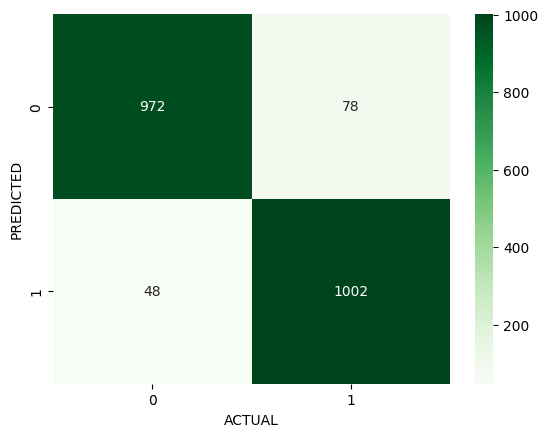

In [42]:
cm= confusion_matrix(test_labels,model_predicted_class)

ax = plt.axes()
sns.heatmap(cm,annot = True,fmt='d',ax = ax,cmap = 'Greens')
ax.set_xlabel("ACTUAL")
ax.set_ylabel("PREDICTED")


<h1> Exploring multiple model and weight storage strategies </h1>

In [43]:
model.save("my_model_1.h5")

In [45]:
model_load = load_model("my_model_1.h5")

In [46]:
model_load.get_weights()

[array([[ 0.5307963 , -0.07357353, -0.22933003, -0.18506089,  0.3255682 ,
         -0.07206792,  0.58457714,  0.33450875, -0.1840483 ,  0.01499567,
          0.5712558 , -0.13468897,  0.56523937,  0.4244645 , -0.08577514,
          0.36121744]], dtype=float32),
 array([-0.16504201,  0.        ,  0.        ,  0.        , -0.06793333,
         0.        , -0.15562668, -0.11867629,  0.        , -0.01521164,
        -0.1331647 ,  0.        , -0.11519293, -0.12293344,  0.        ,
         0.2479987 ], dtype=float32),
 array([[-5.24805307e-01,  4.22473624e-02, -2.99716711e-01,
          4.07811940e-01, -4.95728344e-01, -3.11701775e-01,
          2.82220125e-01, -2.76594281e-01,  2.71378994e-01,
          2.78156877e-01, -3.39914829e-01, -1.89117968e-01,
         -3.36640269e-01, -3.32142025e-01,  2.85265237e-01,
          1.43175751e-01, -2.73858625e-02, -3.36112767e-01,
          4.73464996e-01, -7.63000548e-02,  2.08551928e-01,
         -1.90544128e-02,  2.37885207e-01, -5.32207489e-02,
 

In [47]:
model_load.optimizer

In [48]:
model_load.metrics

[<Mean name=loss>, <CompileMetrics name=compile_metrics>]

In [50]:
model_load.count_params()

642

In [55]:
model_load.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 16)             │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 644 (2.52 KB)

 Trainable params: 642 (2.51 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [53]:
json_string = model.to_json()

model_load_json = model_from_json(json_string)


In [54]:
model_load_json

<Sequential name=sequential_2, built=True>

In [56]:
model_load_json.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 16)             │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,286 (5.03 KB)

 Trainable params: 642 (2.51 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 644 (2.52 KB)

In [57]:
model_load_json.get_weights()

[array([[ 0.4376105 , -0.01895988,  0.22936046, -0.06467956, -0.04410386,
          0.07673723,  0.4404726 , -0.37351012,  0.5217824 , -0.42708403,
         -0.218546  ,  0.36286008,  0.09990519,  0.43740213,  0.48850083,
          0.09621853]], dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       dtype=float32),
 array([[ 0.2493951 ,  0.02525026,  0.00501251,  0.17545345,  0.07673684,
         -0.18562163, -0.04071411, -0.12250075, -0.186122  , -0.14662543,
         -0.18337226, -0.05437407,  0.02756235, -0.3135138 , -0.23530266,
         -0.30587155,  0.04476383, -0.10652447,  0.20316264, -0.07585993,
          0.09825331,  0.05772862,  0.04080084, -0.10952263,  0.32552353,
         -0.1857678 ,  0.12229246,  0.2545472 ,  0.2155383 , -0.04681638,
          0.07882091, -0.28178024],
        [-0.1270113 , -0.15058589, -0.15581529,  0.16698405, -0.19810982,
         -0.2705503 ,  0.3213037 ,  0.16755566, -0.30081174,  0.18079993,
         -0.03

In [58]:
model_load_json.optimizer

In [68]:
model_load.get_weights()


[array([[ 0.5307963 , -0.07357353, -0.22933003, -0.18506089,  0.3255682 ,
         -0.07206792,  0.58457714,  0.33450875, -0.1840483 ,  0.01499567,
          0.5712558 , -0.13468897,  0.56523937,  0.4244645 , -0.08577514,
          0.36121744]], dtype=float32),
 array([-0.16504201,  0.        ,  0.        ,  0.        , -0.06793333,
         0.        , -0.15562668, -0.11867629,  0.        , -0.01521164,
        -0.1331647 ,  0.        , -0.11519293, -0.12293344,  0.        ,
         0.2479987 ], dtype=float32),
 array([[-5.24805307e-01,  4.22473624e-02, -2.99716711e-01,
          4.07811940e-01, -4.95728344e-01, -3.11701775e-01,
          2.82220125e-01, -2.76594281e-01,  2.71378994e-01,
          2.78156877e-01, -3.39914829e-01, -1.89117968e-01,
         -3.36640269e-01, -3.32142025e-01,  2.85265237e-01,
          1.43175751e-01, -2.73858625e-02, -3.36112767e-01,
          4.73464996e-01, -7.63000548e-02,  2.08551928e-01,
         -1.90544128e-02,  2.37885207e-01, -5.32207489e-02,
 

In [69]:
print(len(model_load.get_weights()))

6


In [70]:
model_load.get_weights()[0]

array([[ 0.5307963 , -0.07357353, -0.22933003, -0.18506089,  0.3255682 ,
        -0.07206792,  0.58457714,  0.33450875, -0.1840483 ,  0.01499567,
         0.5712558 , -0.13468897,  0.56523937,  0.4244645 , -0.08577514,
         0.36121744]], dtype=float32)

In [71]:
model_load.get_weights()[1]

array([-0.16504201,  0.        ,  0.        ,  0.        , -0.06793333,
        0.        , -0.15562668, -0.11867629,  0.        , -0.01521164,
       -0.1331647 ,  0.        , -0.11519293, -0.12293344,  0.        ,
        0.2479987 ], dtype=float32)

In [ ]:
model_load.get_weights()[2]

(16, 32)

In [77]:
model_load.get_weights()[3].shape

(32,)

In [ ]:
model_load.get_weights()[4].shape

(32, 2)

In [80]:
model_load.get_weights()[5]

array([ 0.10475083, -0.10475084], dtype=float32)